In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

Dataset dimensions (rows and columns)

In [4]:
df.shape

(7043, 21)

Data types of all attributes

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Basic statistical summary

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Feature names

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [13]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


Duplicate record analysis

In [14]:
print(df.duplicated().sum())

0


Removing duplicate records

As you see there's no duplicate value on dataset so, not drop any value.



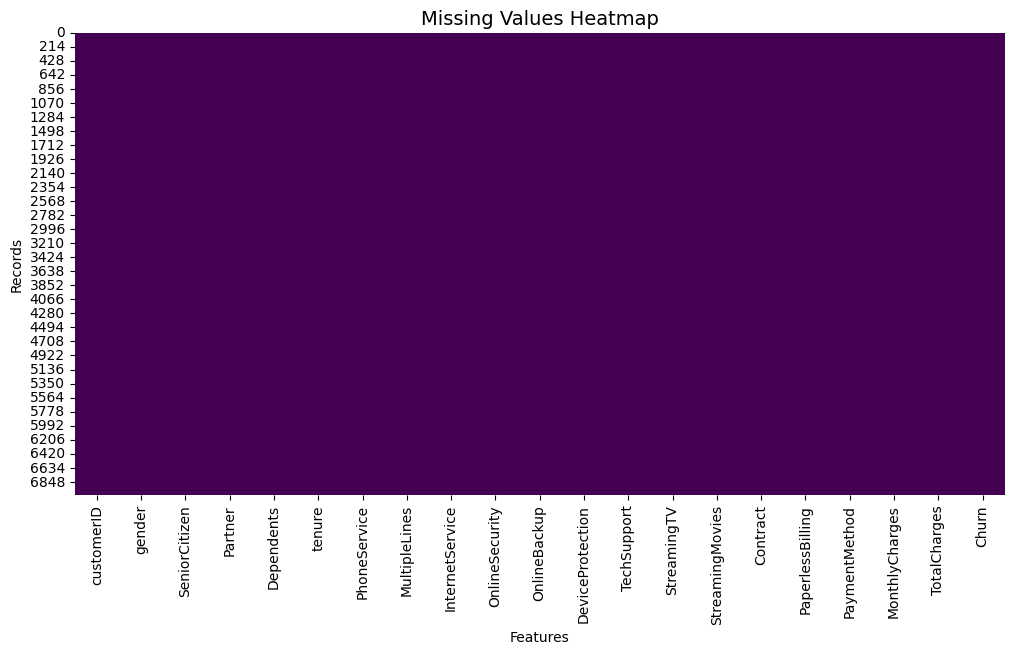

In [15]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

Number of missing values

In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Handling missing values

In [18]:
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=df[col].fillna(df[col].mode()[0])
  else:
    df[col]=df[col].fillna(df[col].median())

Encoding categorical variables

In [19]:
categorial_cols=df.select_dtypes(include="object").columns
for col in categorial_cols:
  df[col]=LabelEncoder().fit_transform(df[col])


In [20]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1


Feature scaling

In [21]:
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [22]:
df.head()
df.describe()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7.043000e+03,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7.043000e+03,7.043000e+03,7043.000000
mean,3521.000000,0.504756,0.162147,0.483033,0.299588,-2.421273e-17,0.903166,0.940508,0.872923,0.790004,...,0.904444,0.797104,0.985376,0.992475,0.690473,0.592219,1.574329,-6.406285e-17,2.623046e-17,0.265370
std,2033.283305,0.500013,0.368612,0.499748,0.458110,1.000071e+00,0.295752,0.948554,0.737796,0.859848,...,0.879949,0.861551,0.885002,0.885091,0.833755,0.491457,1.068104,1.000071e+00,1.000071e+00,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,-1.318165e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.545860e+00,-1.725015e+00,0.000000
25%,1760.500000,0.000000,0.000000,0.000000,0.000000,-9.516817e-01,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-9.725399e-01,-8.730433e-01,0.000000
50%,3521.000000,1.000000,0.000000,0.000000,0.000000,-1.372744e-01,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.857327e-01,-4.656524e-03,0.000000
75%,5281.500000,1.000000,0.000000,1.000000,1.000000,9.214551e-01,1.000000,2.000000,1.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,8.338335e-01,8.703490e-01,1.000000
max,7042.000000,1.000000,1.000000,1.000000,1.000000,1.613701e+00,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,1.794352e+00,1.732647e+00,1.000000


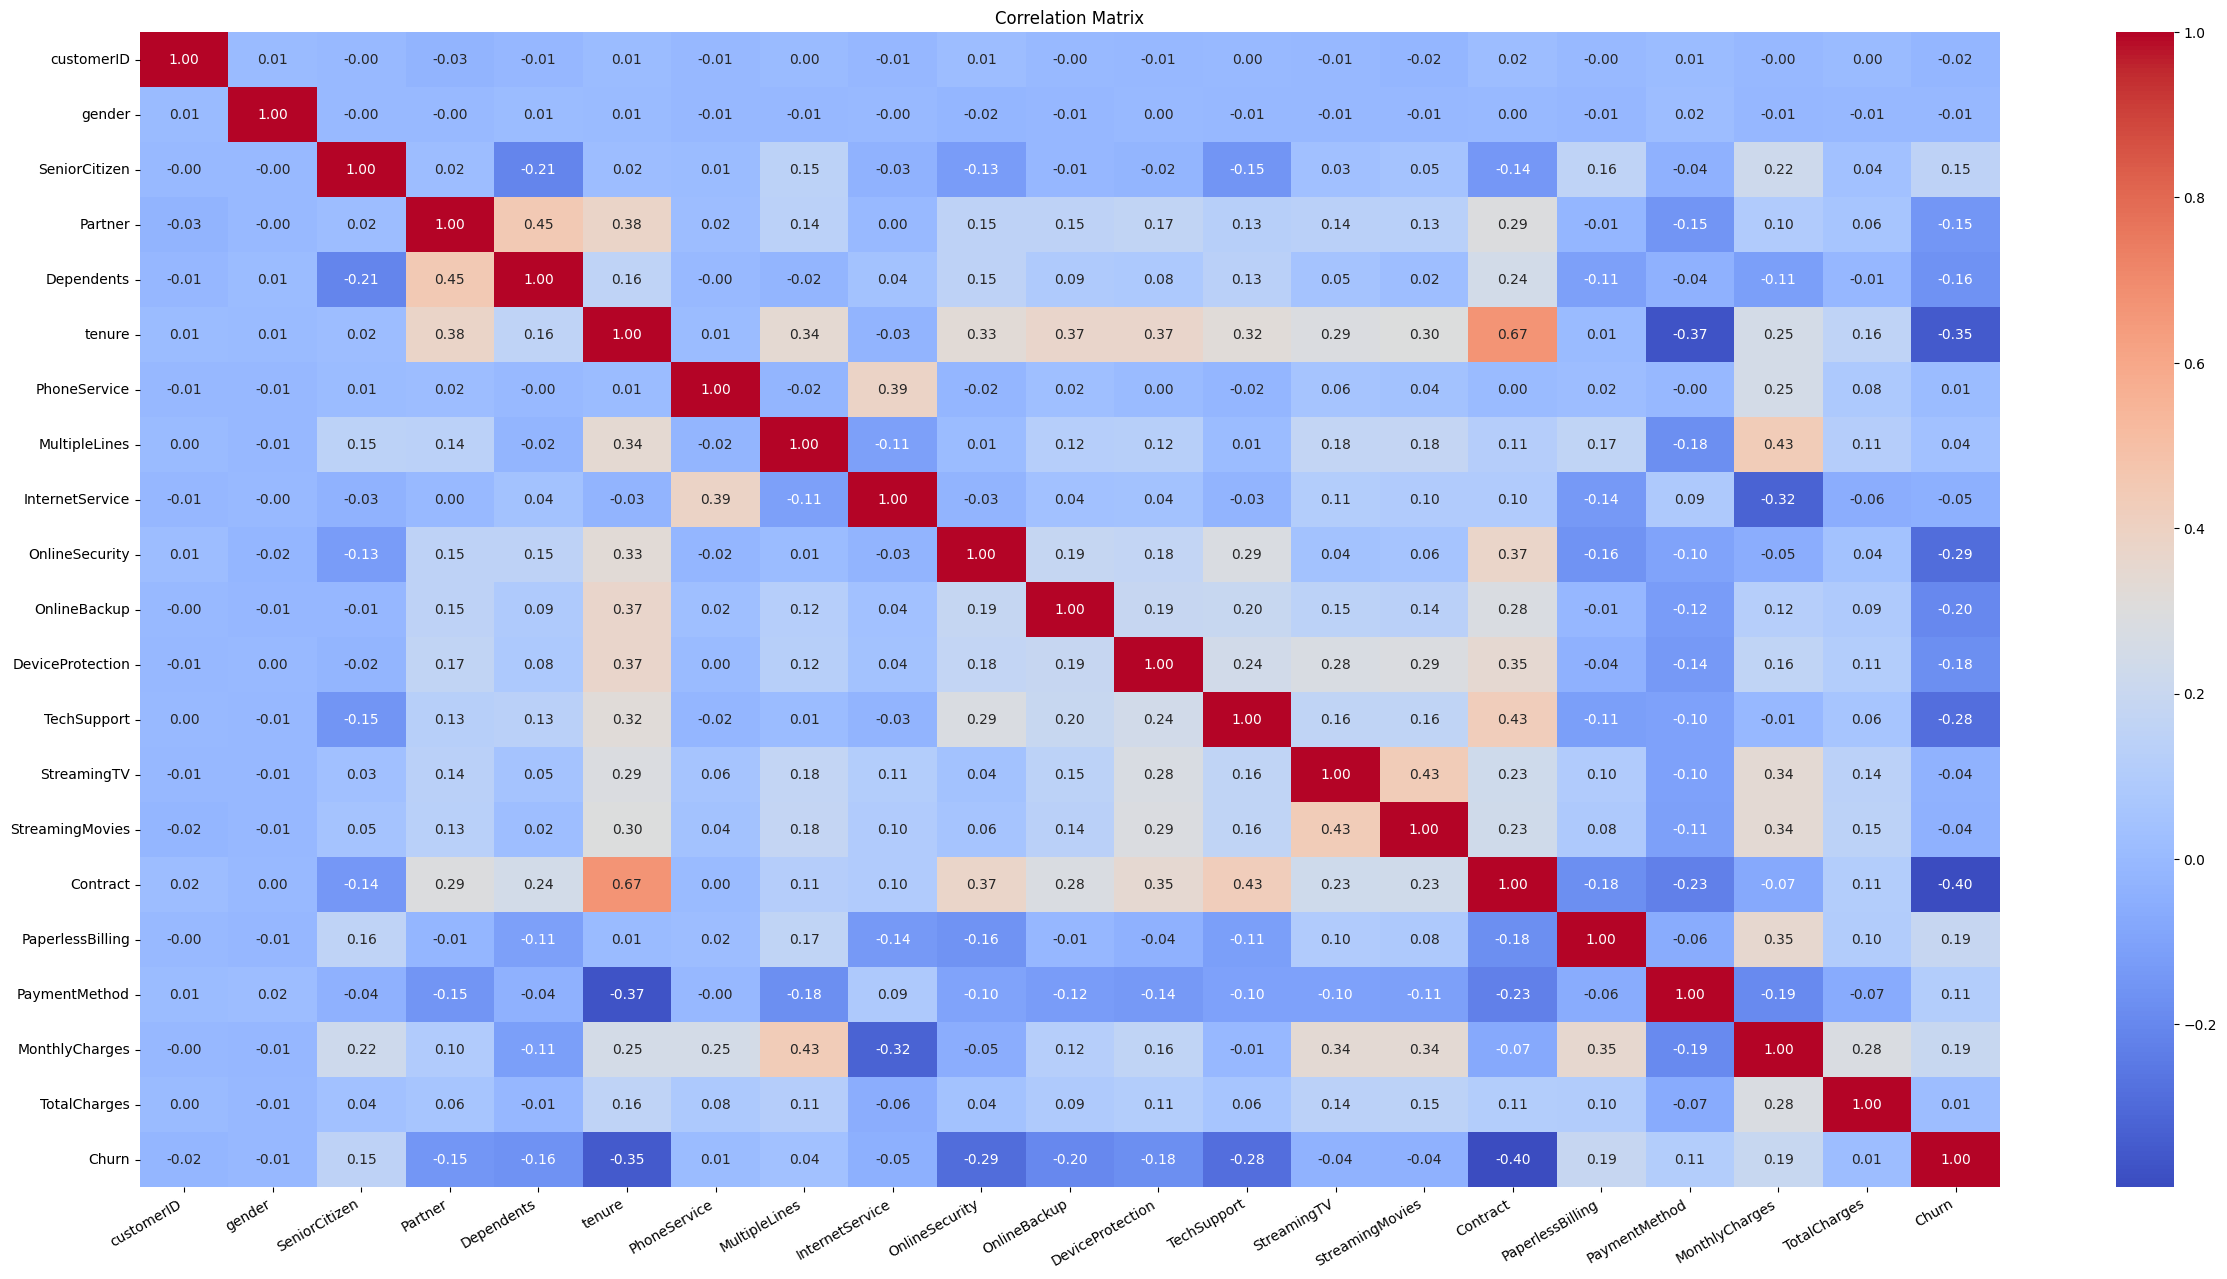

In [23]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(30,15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Matrix")
plt.xticks(rotation=30, ha='right')
plt.show()

Remove Irrelevant Features

In [24]:
df.drop(columns=['customerID'], inplace=True)

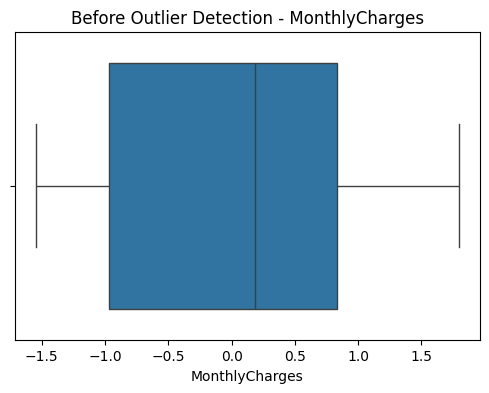

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['MonthlyCharges'])
plt.title('Before Outlier Detection - MonthlyCharges')
plt.show()

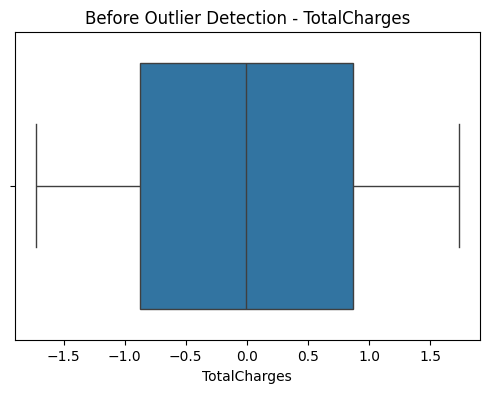

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['TotalCharges'])
plt.title('Before Outlier Detection - TotalCharges')
plt.show()

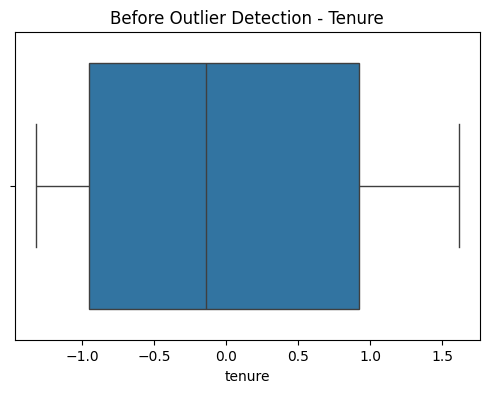

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['tenure'])
plt.title('Before Outlier Detection - Tenure')
plt.show()

Detecting and treating outliers

In [28]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['MonthlyCharges'] >= lower_bound) &
        (df['MonthlyCharges'] <= upper_bound)]

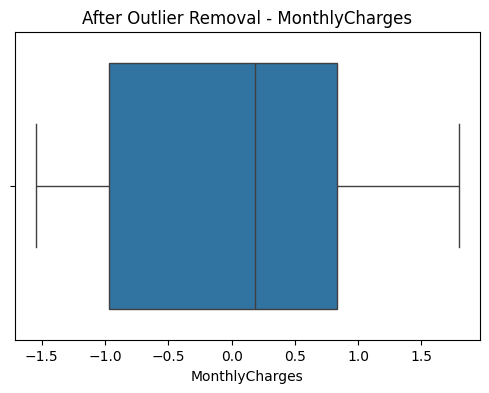

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['MonthlyCharges'])
plt.title('After Outlier Removal - MonthlyCharges')
plt.show()

In [30]:
Q1 = df['tenure'].quantile(0.25)
Q3 = df['tenure'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['tenure'] >= lower_bound) &
        (df['tenure'] <= upper_bound)]

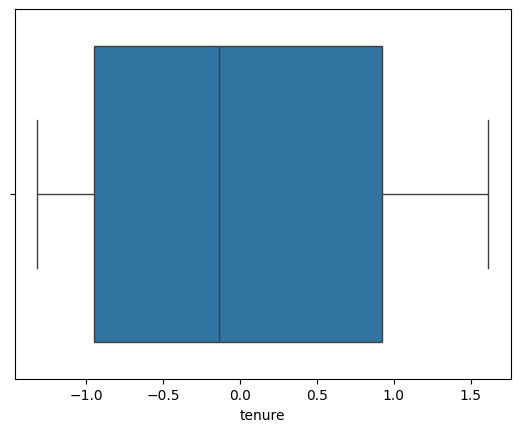

In [31]:
sns.boxplot(x=df['tenure'])
plt.show()

In [32]:
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['TotalCharges'] >= lower_bound) &
        (df['TotalCharges'] <= upper_bound)]

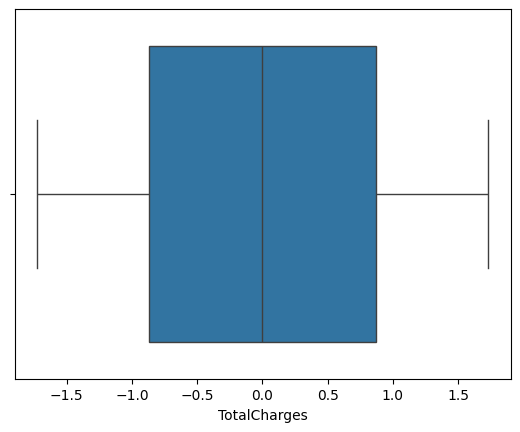

In [33]:
sns.boxplot(x=df['TotalCharges'])
plt.show()

Target variable (if applicable)

In [34]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [35]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [36]:
df.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,float64
PhoneService,int64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64


Class distribution (classification datasets)


Applying imbalance handling

In [37]:
print(f'Original Dataset Size: {y.value_counts()}')
balance = SMOTETomek(random_state=42)
X_resampled, y_resampled = balance.fit_resample(X, y)

# Check new class distribution
print("\nResampled Dataset Size:")
print(y_resampled.value_counts())

Original Dataset Size: Churn
0    5174
1    1869
Name: count, dtype: int64

Resampled Dataset Size:
Churn
0    5001
1    5001
Name: count, dtype: int64


In [38]:
df.to_csv("cleaned_dataset.csv", index=False)

Creating New Features

In [39]:
df['IsSenior'] = (df['SeniorCitizen'] == 1).astype(int)

Feature Transformation

In [40]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [41]:
df['TotalCharges'] = np.log1p(df['TotalCharges'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Date & Time Feature Extraction

Not applicable because the dataset does not contain any date or time attributes.

Text Feature Extraction

Not applicable because the dataset contains no textual features.

Feature Selection

In [42]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_new = selector.fit_transform(X, y)

**Visualizations**

CountPlot:

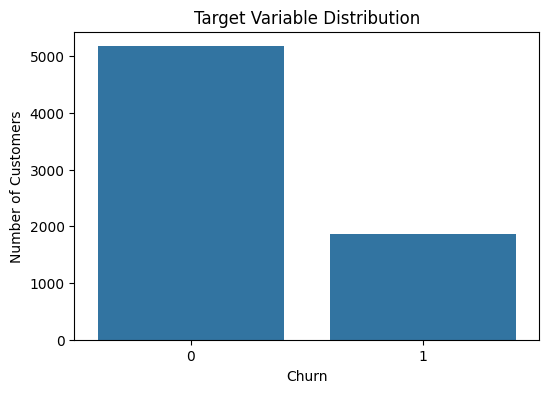

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Target Variable Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Histogram

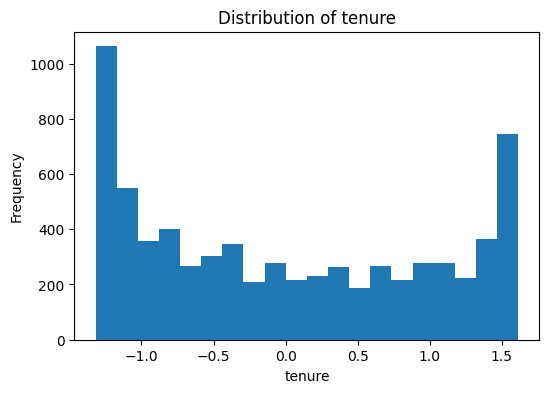

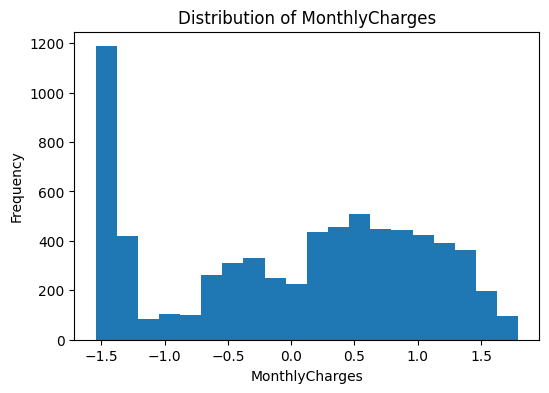

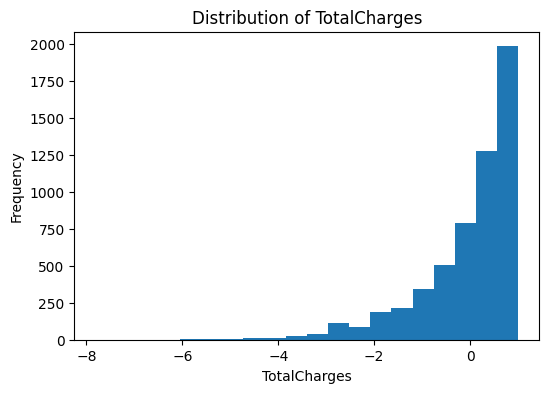

In [45]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

BoxPlot:

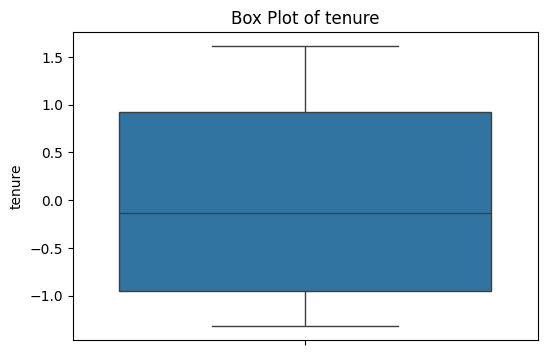

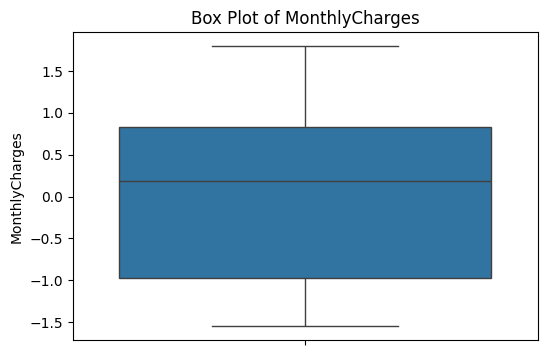

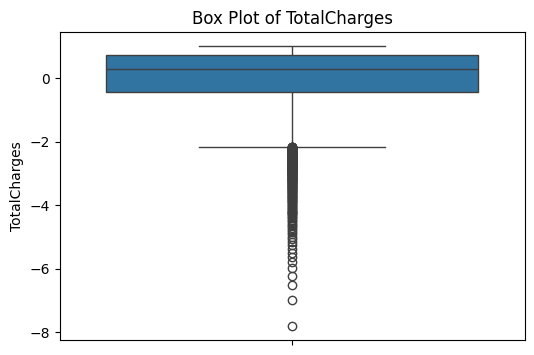

In [46]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])

    plt.title(f"Box Plot of {col}")
    plt.xlabel("")
    plt.ylabel(col)

    plt.show()

ScatterPlot:

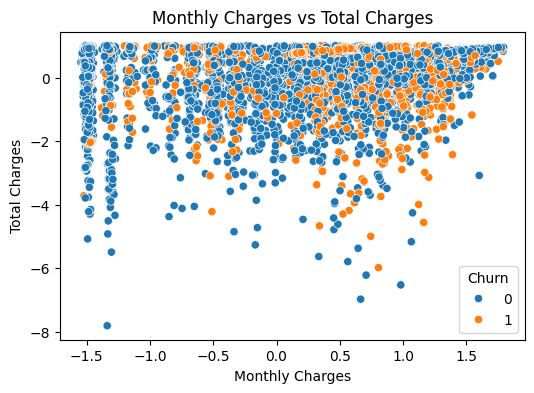

In [47]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Churn',
    data=df
)

plt.title("Monthly Charges vs Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")

plt.show()

HeatMap:

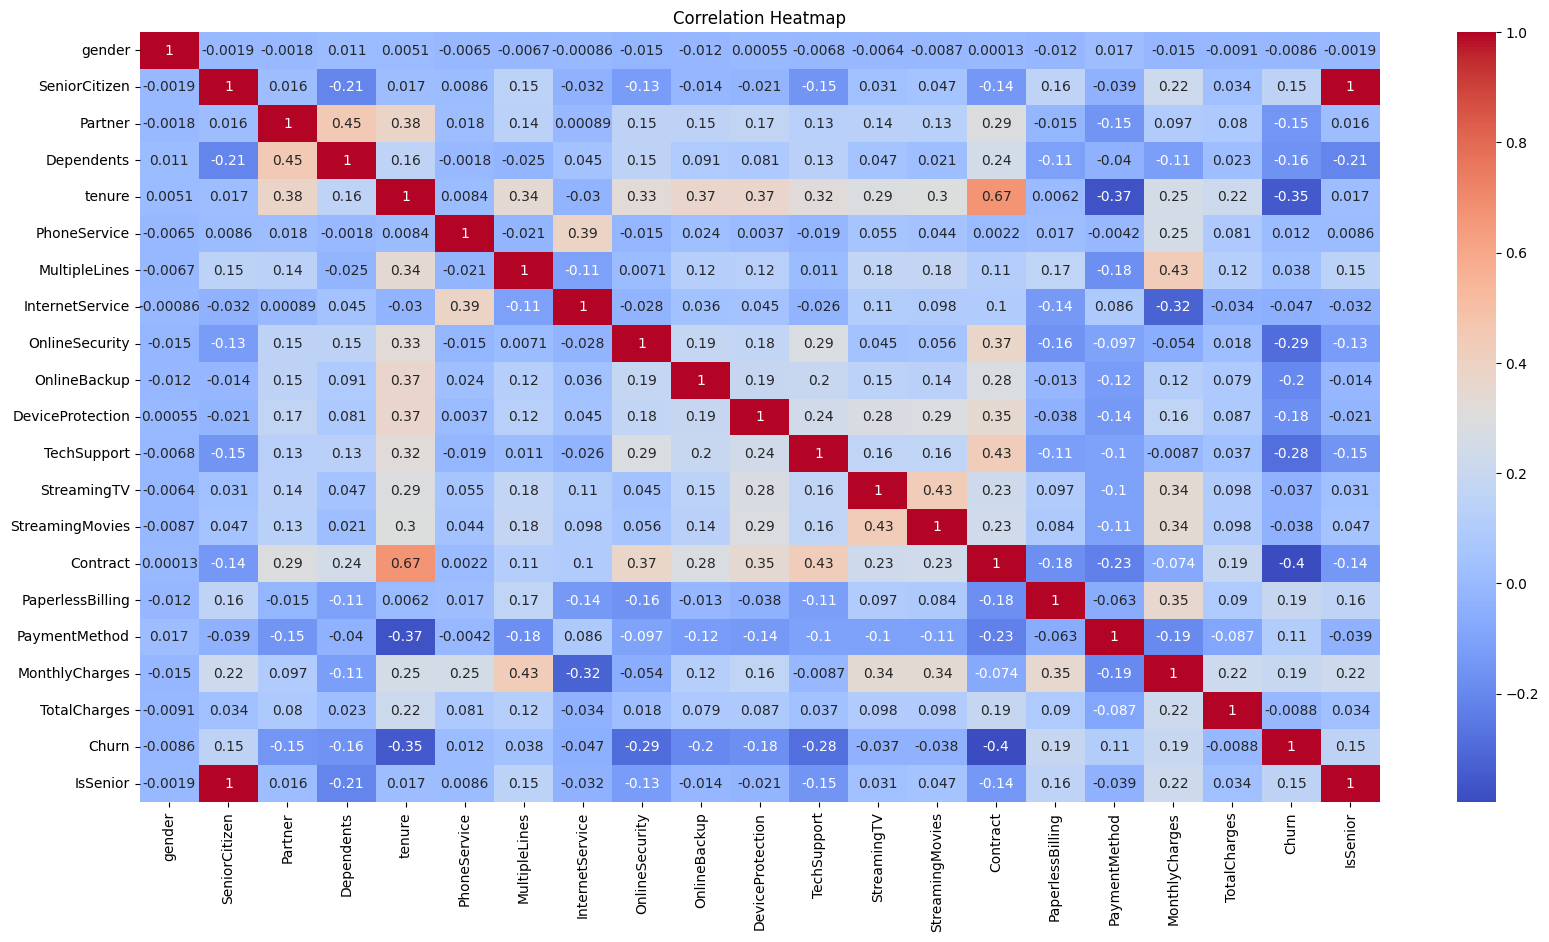

In [48]:
plt.figure(figsize=(20,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

ViolinPlot:

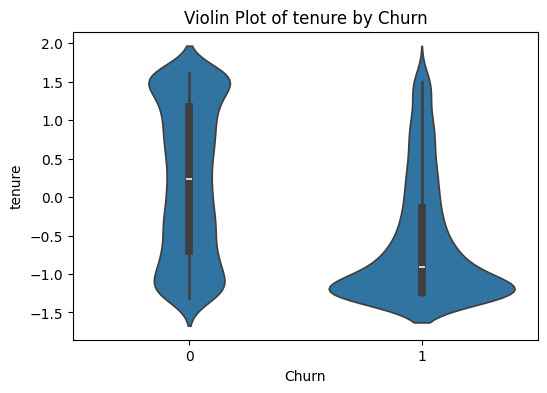

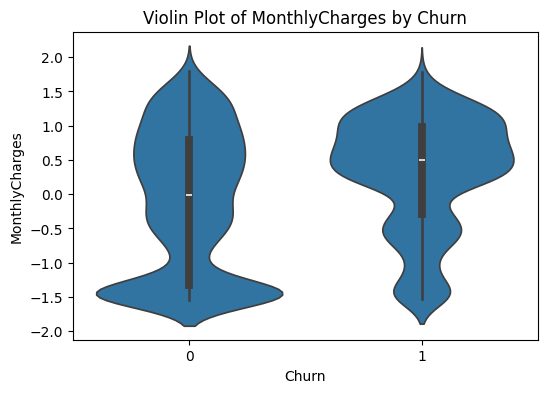

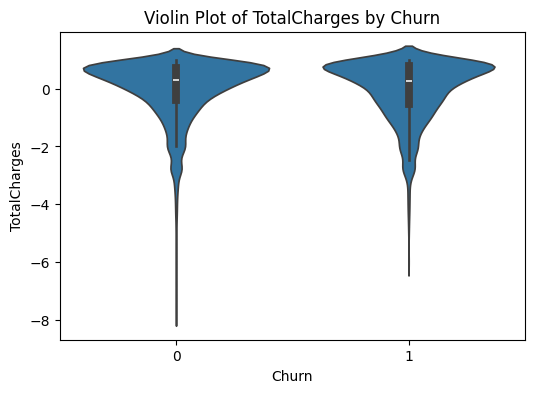

In [49]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.violinplot(x='Churn', y=col, data=df)

    plt.title(f"Violin Plot of {col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)

    plt.show()

Count Plot per Feature:

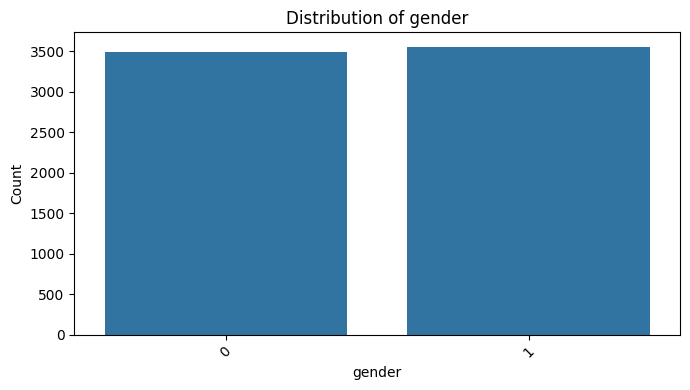

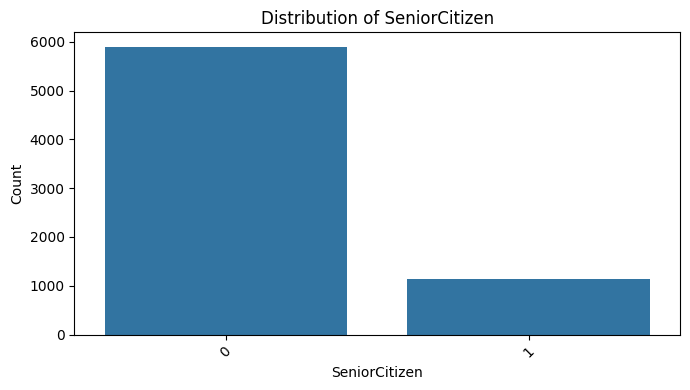

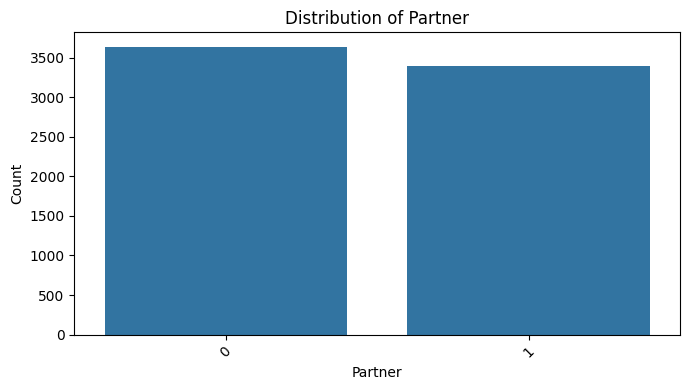

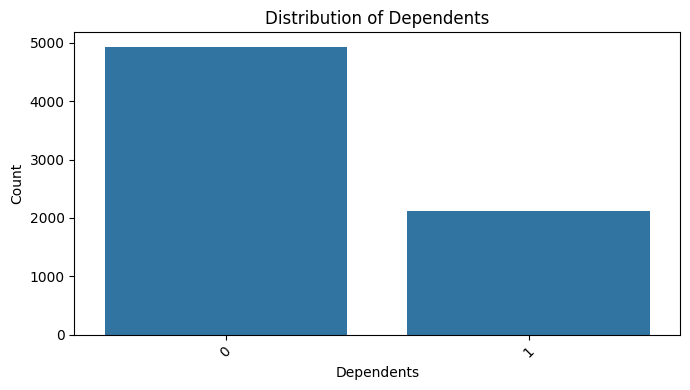

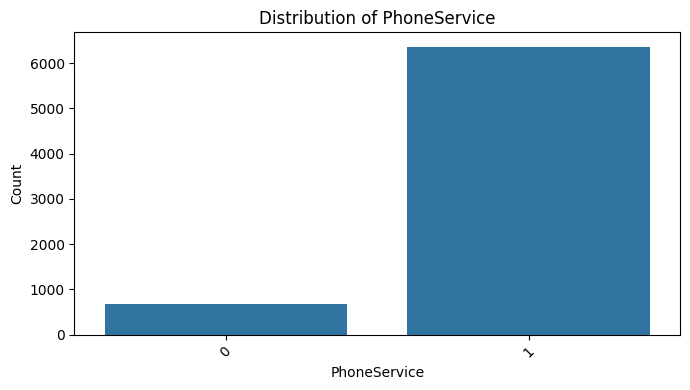

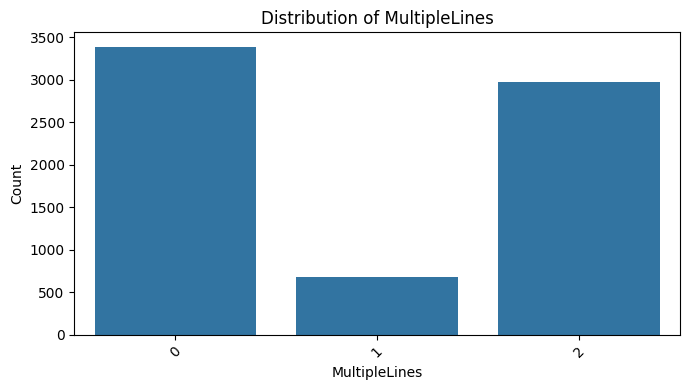

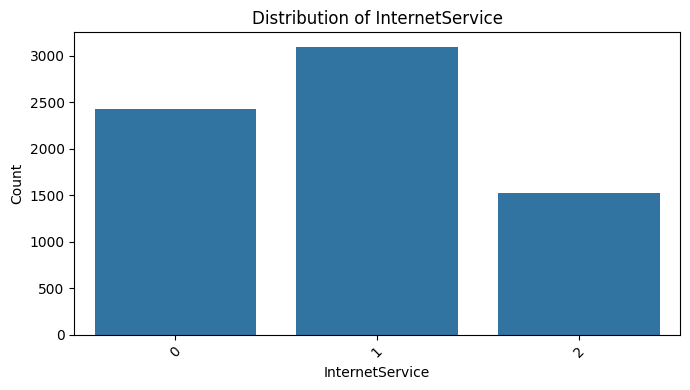

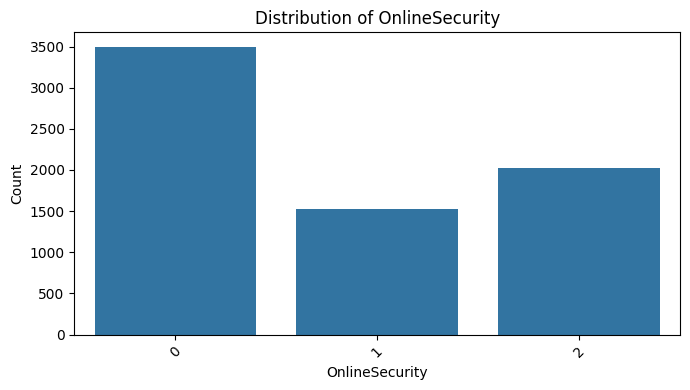

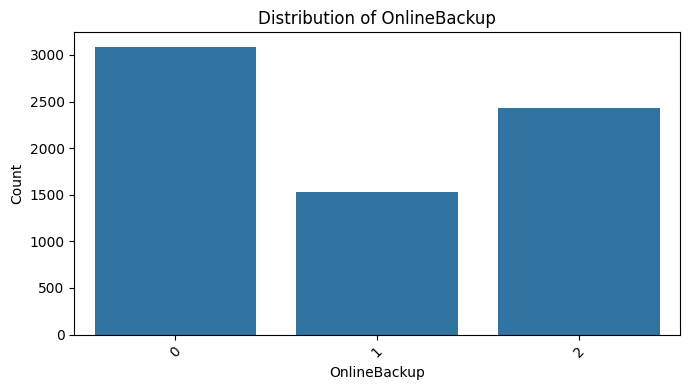

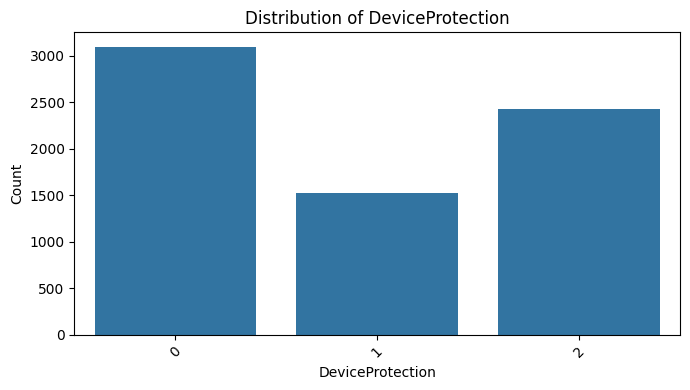

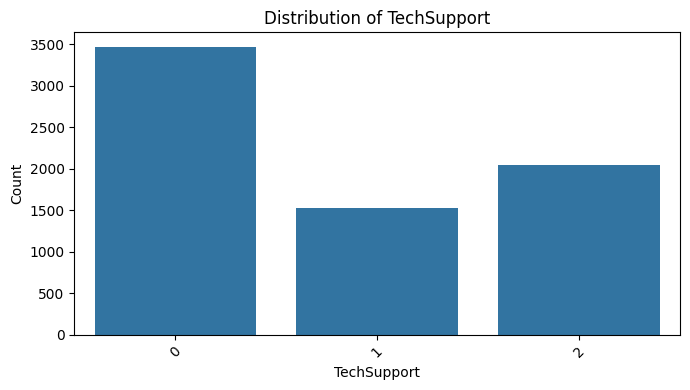

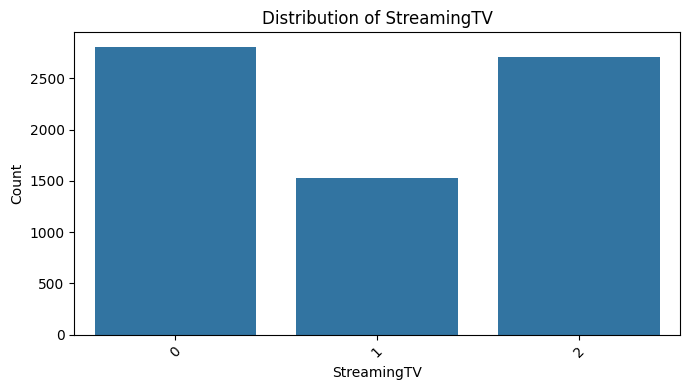

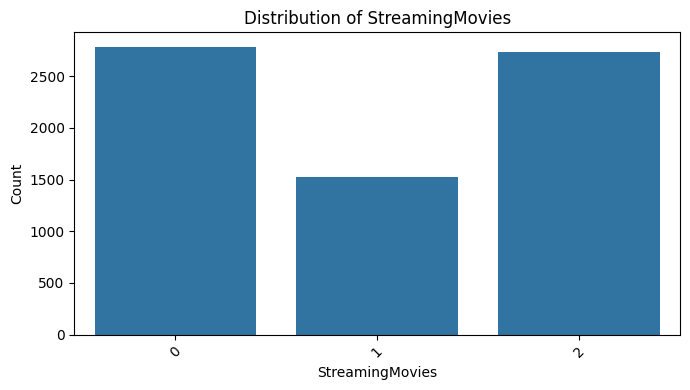

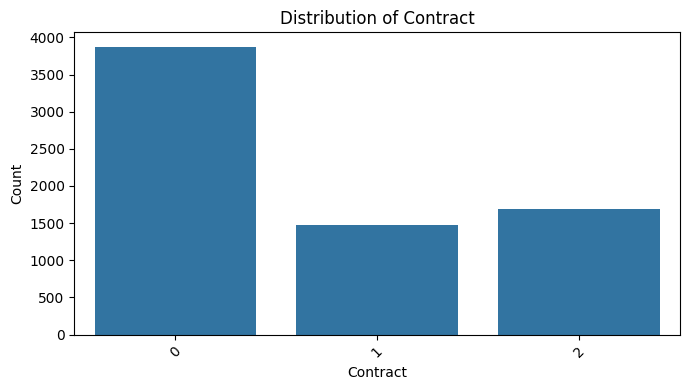

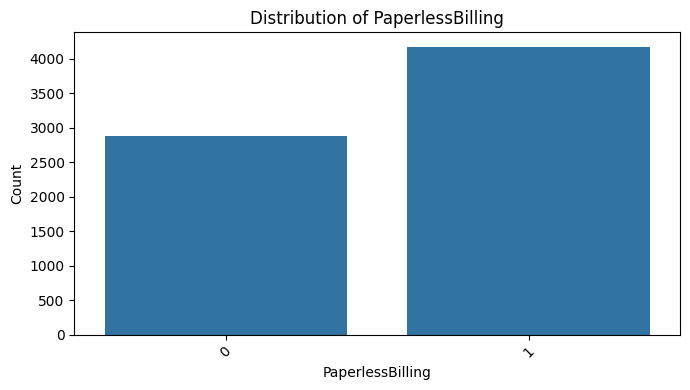

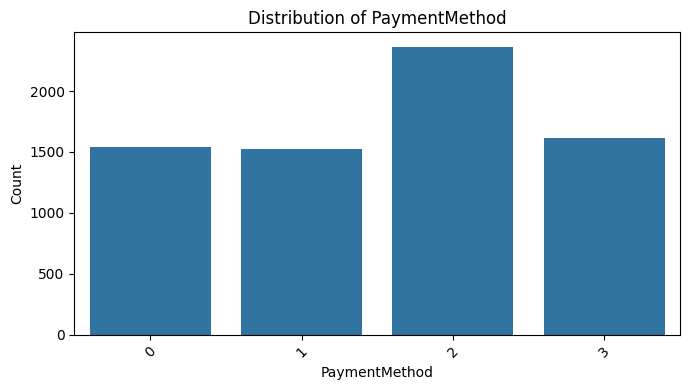

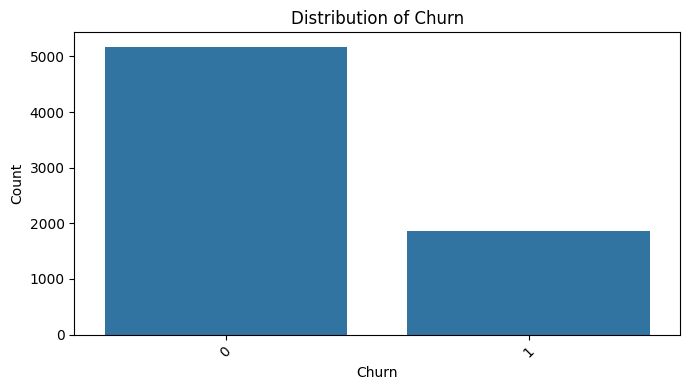

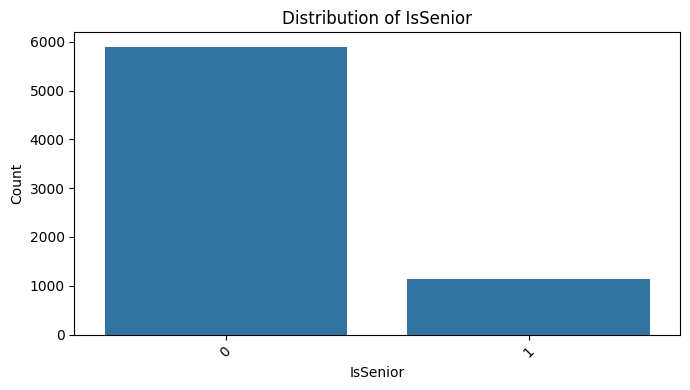

In [50]:
categorical_cols = df.select_dtypes(include=['int']).columns

for col in categorical_cols:
    plt.figure(figsize=(7,4))

    sns.countplot(x=col, data=df)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

Pie Chart Per Ctegory:

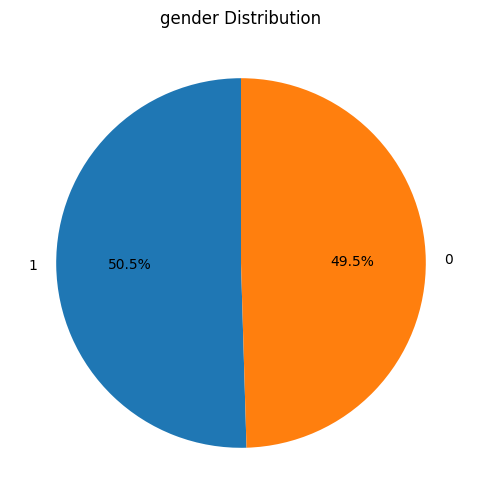

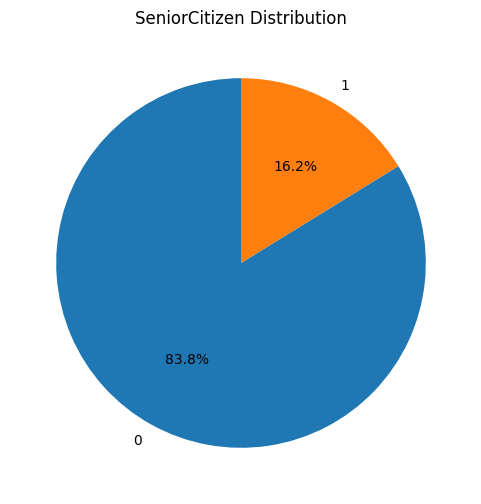

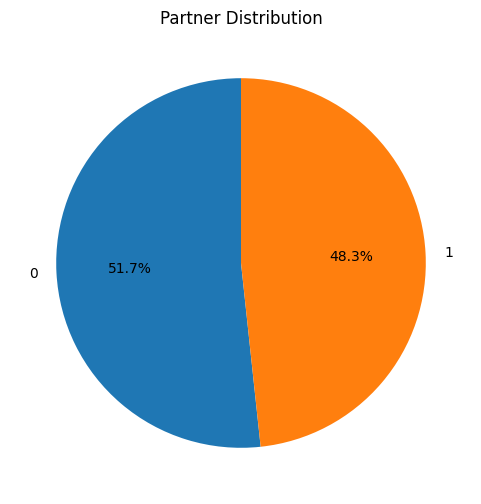

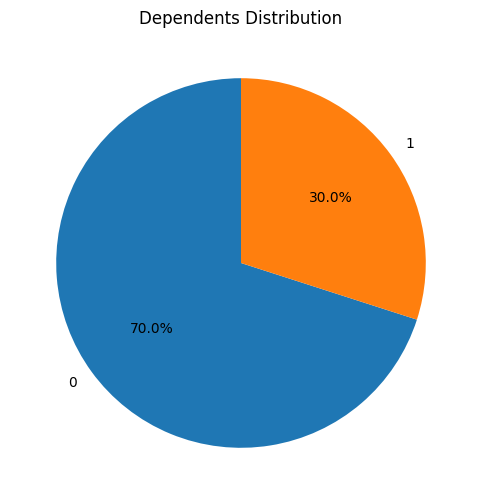

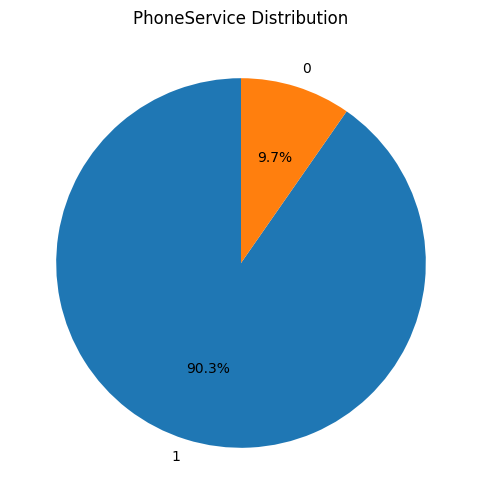

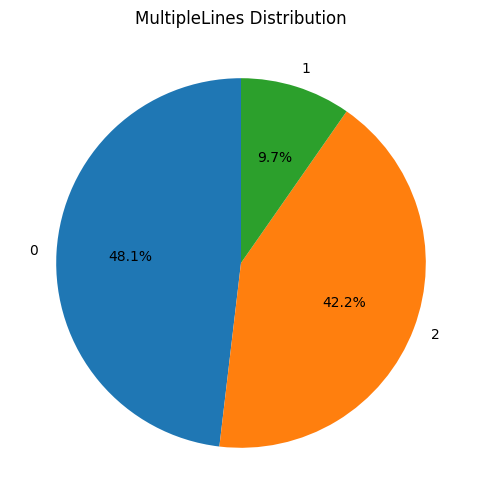

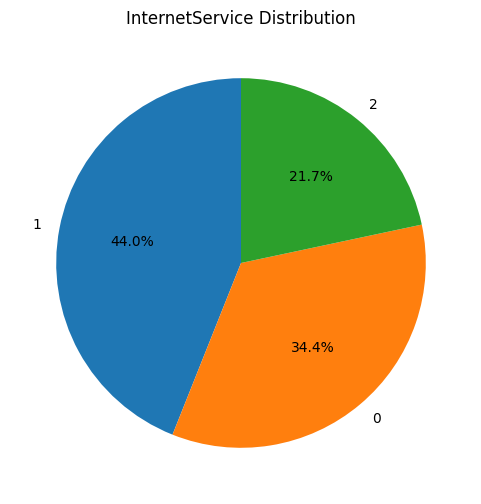

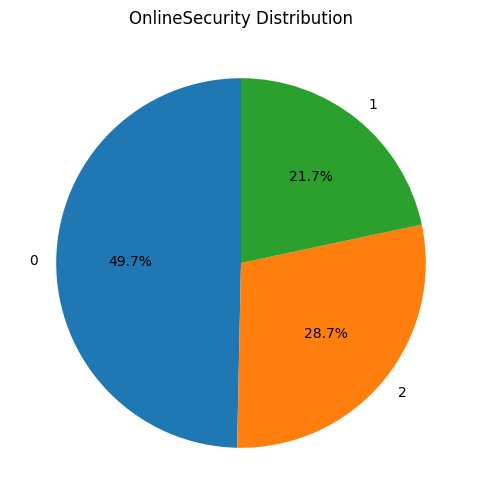

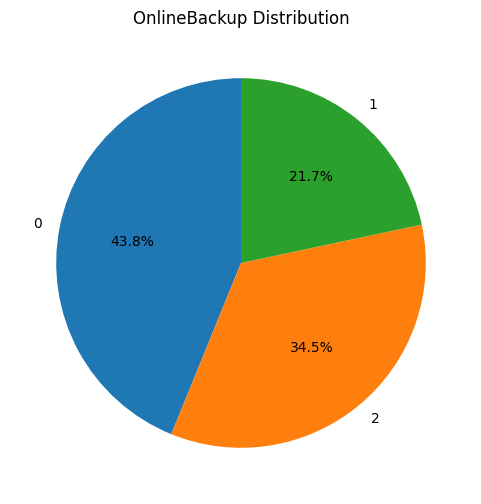

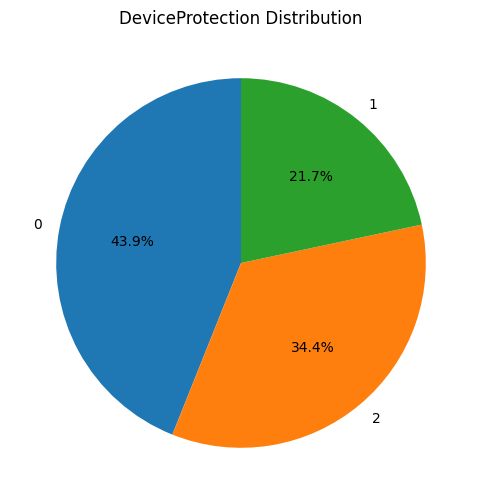

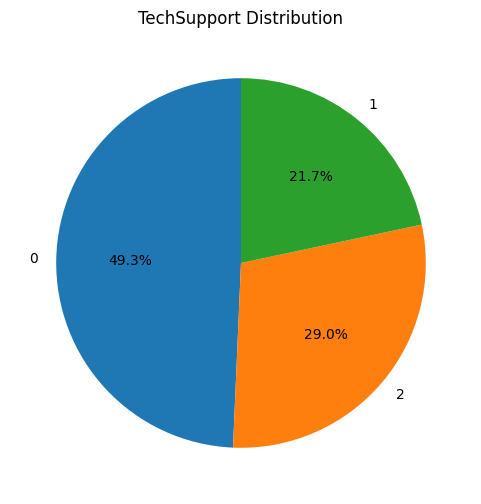

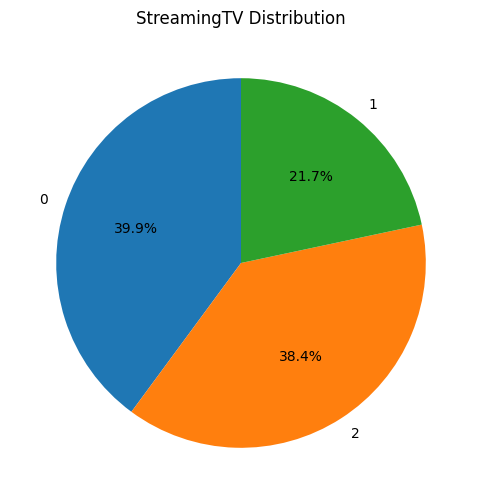

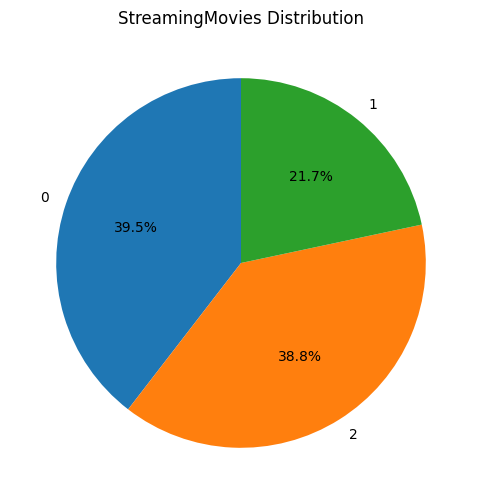

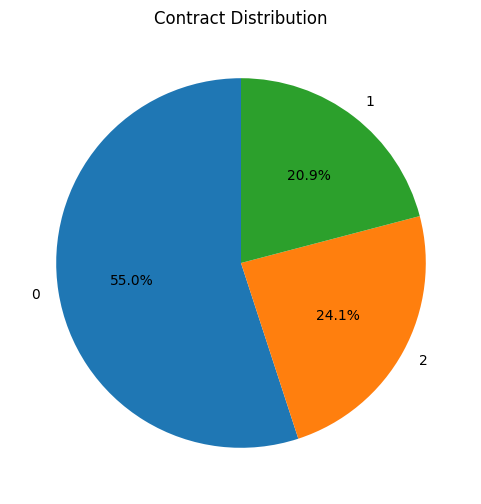

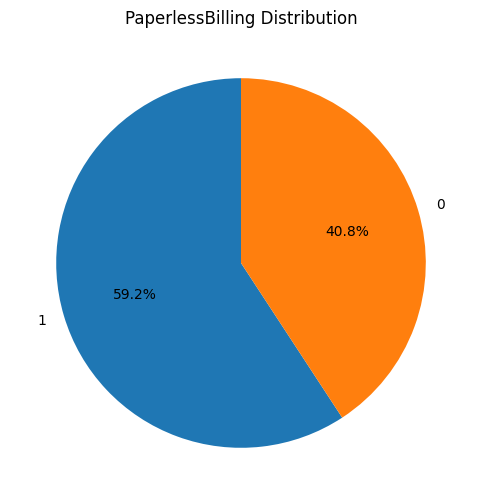

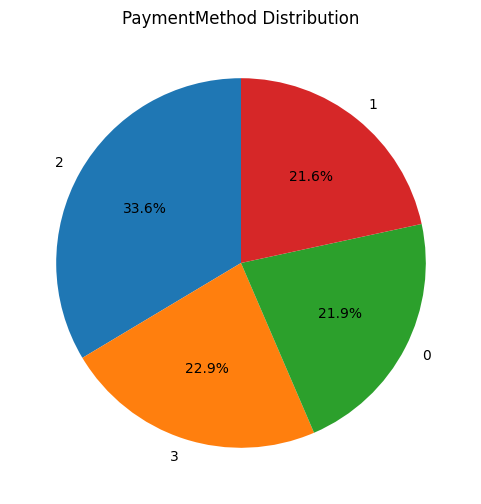

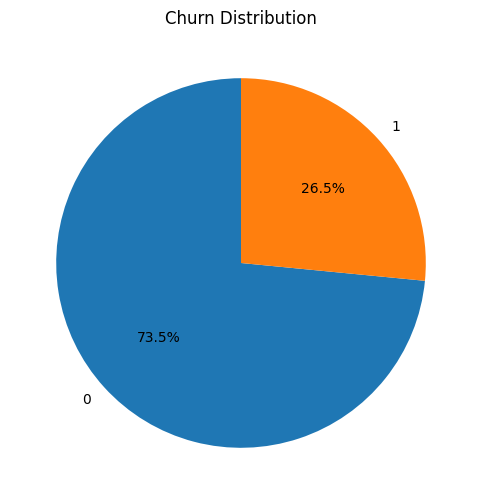

In [51]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

for col in categorical_cols:
    plt.figure(figsize=(6,6))

    df[col].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        startangle=90
    )

    plt.title(f"{col} Distribution")
    plt.ylabel("")  # Removes the default y-axis label
    plt.show()

KDE Plot:

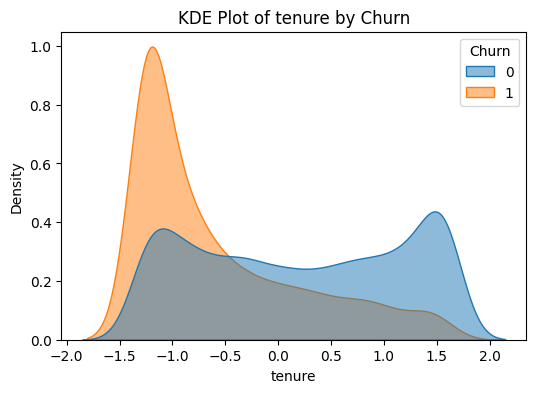

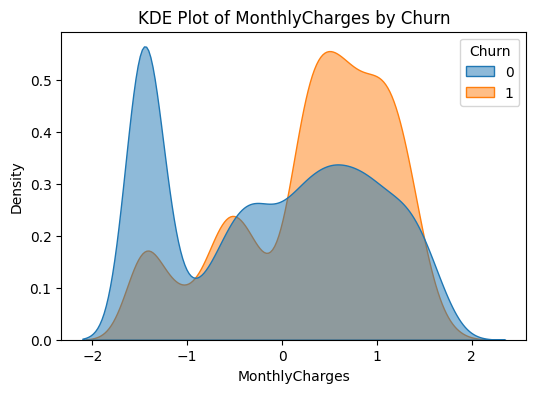

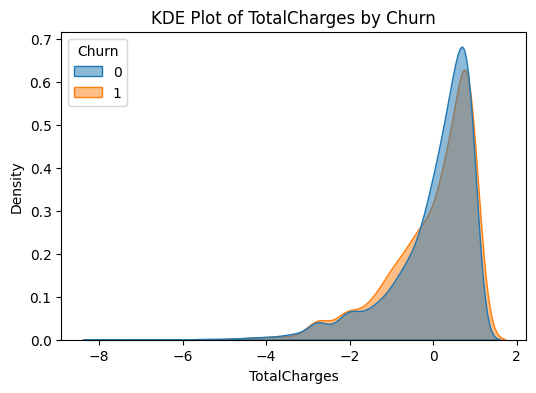

In [52]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.kdeplot(
        data=df,
        x=col,
        hue='Churn',
        fill=True,
        common_norm=False,
        alpha=0.5
    )

    plt.title(f"KDE Plot of {col} by Churn")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.show()

3D Scatter Plot:

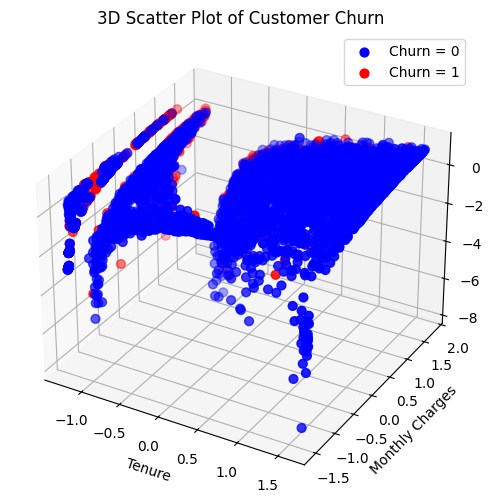

In [53]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

x = df['tenure']
y = df['MonthlyCharges']
z = df['TotalCharges']

classes = df['Churn']

colors = ['blue', 'red']

for cls, color in zip(sorted(df['Churn'].unique()), colors):
    mask = df['Churn'] == cls
    ax.scatter(
        x[mask],
        y[mask],
        z[mask],
        color=color,
        label=f'Churn = {cls}',
        s=40
    )

ax.set_xlabel("Tenure")
ax.set_ylabel("Monthly Charges")
ax.set_zlabel("Total Charges")
ax.set_title("3D Scatter Plot of Customer Churn")

ax.legend()

plt.show()

Density Plot:

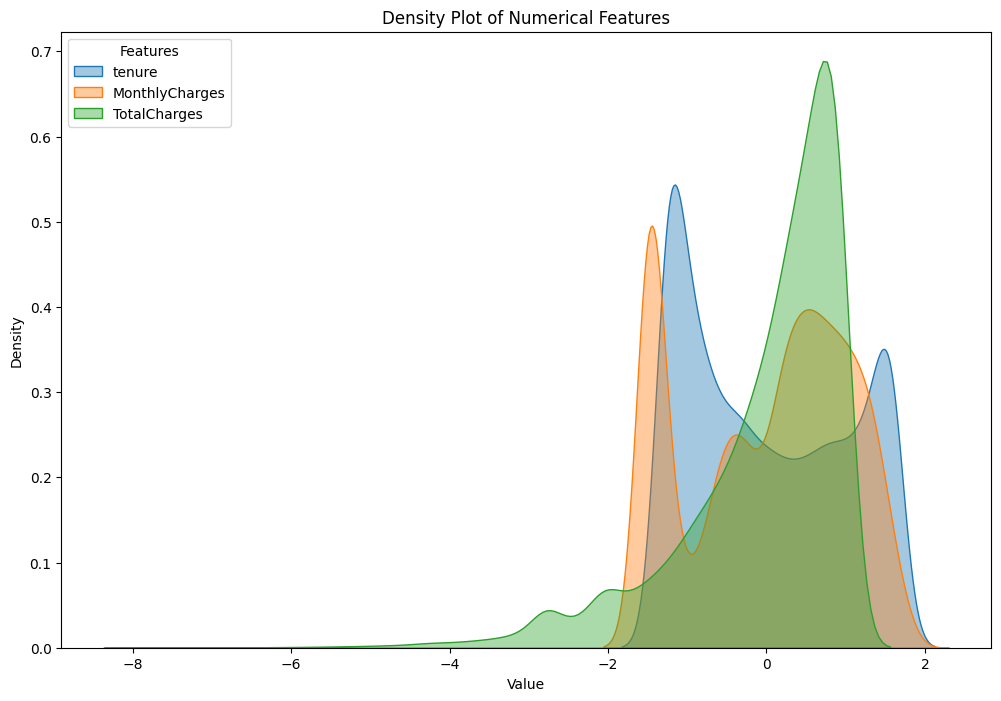

In [54]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(12,8))

for col in numeric_cols:
    sns.kdeplot(
        data=df,
        x=col,
        fill=True,
        label=col,
        alpha=0.4
    )

plt.title("Density Plot of Numerical Features")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend(title="Features")

plt.show()

Strip Plot:

/tmp/ipykernel_2577/3904461532.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


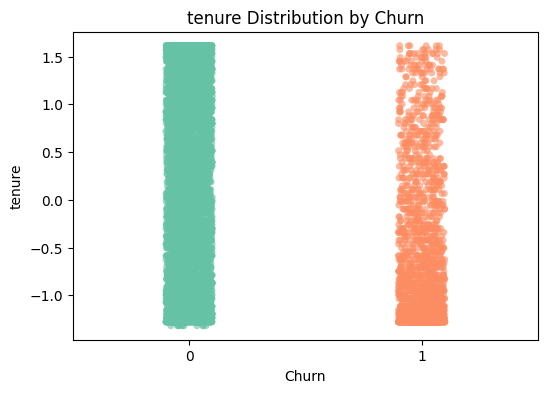

/tmp/ipykernel_2577/3904461532.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


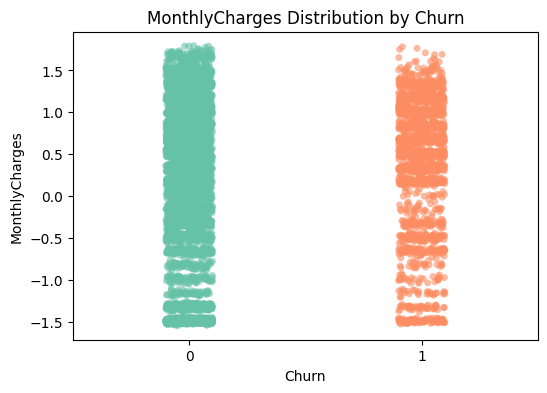

/tmp/ipykernel_2577/3904461532.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


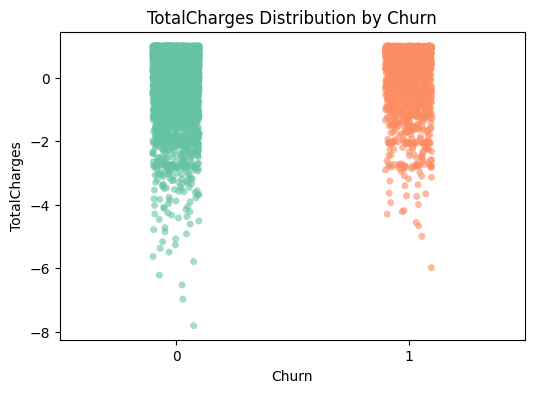

In [56]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.stripplot(
        x='Churn',
        y=col,
        data=df,
        palette='Set2',
        alpha=0.6,
        jitter=True
    )

    plt.title(f"{col} Distribution by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)

    plt.show()

Model Training & Evaluation

In [57]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

Train-Test Split

In [73]:
y = df['Churn']

X = df.drop('Churn', axis=1)

In [74]:
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Feature Scaling

In [76]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Logistic Regression

In [77]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

Evaluate Logistic Regression

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.8005677785663591
Precision: 0.6476190476190476
Recall: 0.5454545454545454
F1 Score: 0.5921625544267054


In [79]:
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



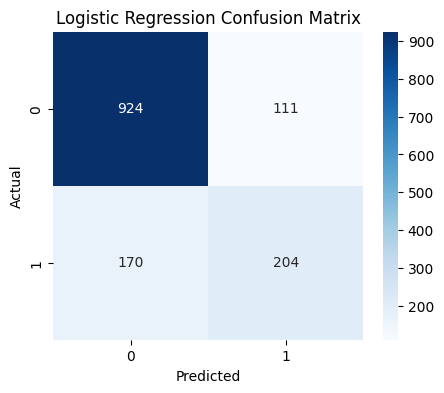

In [80]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Train Random Forest

In [81]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

valuate Random Forest

In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7849538679914834
Precision: 0.6236933797909407
Recall: 0.4786096256684492
F1 Score: 0.5416036308623298


In [91]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



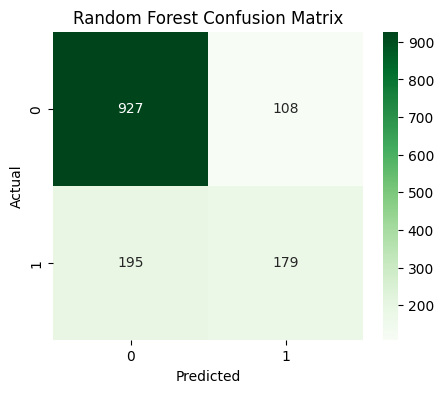

In [83]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Train Support Vector Machine (SVM)

In [84]:
svm = SVC(random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

Evaluate SVM

In [85]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.7955997161107168
Precision: 0.6546762589928058
Recall: 0.48663101604278075
F1 Score: 0.558282208588957


In [92]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409



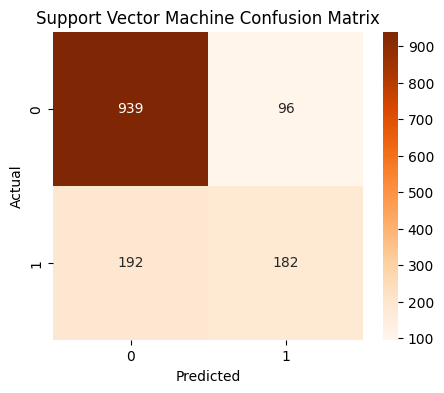

In [86]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Cross Validation

In [90]:
lr_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5)
print("Logistic Regression CV Accuracy:", lr_scores.mean())

rf_scores = cross_val_score(rf, X, y, cv=5)
print("Random Forest CV Accuracy:", rf_scores.mean())

svm_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
print("SVM CV Accuracy:", svm_scores.mean())

Logistic Regression CV Accuracy: 0.8028006260037415
Random Forest CV Accuracy: 0.7917094449641912
SVM CV Accuracy: 0.7953487858963184


Compare Models

In [93]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Random Forest',
              'Support Vector Machine'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ]
})

comparison.to_csv("Model_Comparison.csv", index=False)

Bar Chart Comparison

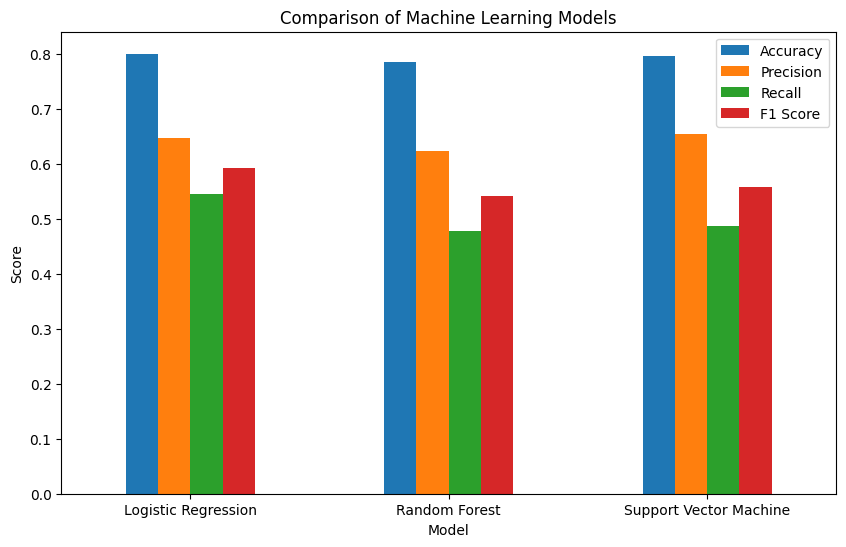

In [89]:
comparison.plot(
    x='Model',
    y=['Accuracy','Precision','Recall','F1 Score'],
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()